# Compare orbit solutions — daily

Compares two orbit solutions (GOP and SSA) day by day in the RTN frame
using Hermite interpolation. Produces daily statistics, epoch-wise
difference series, periodograms, and summary plots.

## Imports

Load standard library modules, third-party packages, and functions from the local `doris` package.

In [1]:
# --- Standard library ---
import sys                                # system-specific parameters
from pathlib import Path                  # filesystem paths
from datetime import date                 # date handling

# --- Third-party packages ---
try:
    import numpy as np                    # numerical arrays
except ImportError as e:
    raise RuntimeError("Missing dependency: 'numpy'. Install it with:\n  pip install numpy") from e

try:
    import pandas as pd                   # tabular dataframes
    pd.set_option("display.float_format", "{:.5f}".format)
except ImportError as e:
    raise RuntimeError("Missing dependency: 'pandas'. Install it with:\n  pip install pandas") from e

try:
    import matplotlib.pyplot as plt       # plotting
except ImportError as e:
    raise RuntimeError("Missing dependency: 'matplotlib'. Install it with:\n  pip install matplotlib") from e

try:
    from scipy.signal import lombscargle  # Lomb-Scargle periodogram
except ImportError as e:
    raise RuntimeError("Missing dependency: 'scipy'. Install it with:\n  pip install scipy") from e

# --- doris package ---
_src = Path("../..").resolve() / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

try:
    from doris.analysis.orbits import (
        compare_trajectories,
        iter_orbit_days,
        load_orbit_day,
        orbit_diff_stats,
        orbit_diff_summary,
    )
    from doris.analysis.orbits.loading import select_file_for_day
except ImportError as e:
    raise RuntimeError(
        "Missing doris modules. Make sure the project src path is on PYTHONPATH "
        "or run the notebook from the expected directory."
    ) from e


## Paths and parameters

Set the satellite, solutions being compared, processing interval, and output locations.

In [2]:
# --- Dataset selection ---
satellite = "h2c"

# --- Solutions ---
REFERENCE_SOLUTION = "gop"
COMPARED_SOLUTION  = "ssa"
SOLUTION_TAG       = f"{REFERENCE_SOLUTION}_vs_{COMPARED_SOLUTION}"

# --- Project paths ---
PROJECT_ROOT = Path("../..").resolve()
DATA_ROOT    = PROJECT_ROOT / "data"

GOP_ROOT    = DATA_ROOT / "orbits" / REFERENCE_SOLUTION / satellite
SSA_ROOT    = DATA_ROOT / "orbits" / COMPARED_SOLUTION  / satellite
RESULTS_DIR = DATA_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "LaTeX" / "images" / "results" / "satellites" / "hermite"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Processing settings ---
START_DATE     = date(2024, 1, 1)
END_DATE       = date(2024, 1, 30)
HERMITE_DEGREE = 11
EDGE_TRIM      = 6

# --- Debug prints ---
print("PROJECT_ROOT:", PROJECT_ROOT)
print("GOP_ROOT:    ", GOP_ROOT)
print("SSA_ROOT:    ", SSA_ROOT)
print("FIGURES_DIR: ", FIGURES_DIR)
print("RESULTS_DIR: ", RESULTS_DIR)


PROJECT_ROOT: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis
GOP_ROOT:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\orbits\gop\h2c
SSA_ROOT:     C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\orbits\ssa\h2c
FIGURES_DIR:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\LaTeX\images\results\satellites\hermite
RESULTS_DIR:  C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results


## Daily processing loop

Load matching GOP and SSA orbit days, compare trajectories in RTN, and store daily differences.

In [3]:
results: dict[date, pd.DataFrame] = {}

for day, gop_df in iter_orbit_days(GOP_ROOT, START_DATE, END_DATE):
    ssa_info = select_file_for_day(SSA_ROOT, day)
    if ssa_info is None:
        continue

    ssa_df = load_orbit_day(SSA_ROOT, day, window=0.5)

    t0 = gop_df["MJD_TAI"].iloc[0]
    gop_df["t_sec"] = (gop_df["MJD_TAI"] - t0) * 86400.0
    ssa_df["t_sec"] = (ssa_df["MJD_TAI"] - t0) * 86400.0

    diff = compare_trajectories(
        ssa_df,
        gop_df,
        time_col="t_sec",
        degree=HERMITE_DEGREE,
        edge_trim=EDGE_TRIM,
        rtn=True,
        unit="m",
    )
    results[day] = diff

print(f"Processed days: {len(results)}")


Processed days: 30


## Daily statistics

Summarize the daily RTN differences for plotting and export.

In [4]:
df_stats = orbit_diff_summary(results)
display(df_stats)

,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0
0,2024-01-01,0.00004,0.00493,0.00196,0.00905,0.02589,0.04268,0.00905,0.02542,0.04263
1,2024-01-02,-0.00037,-0.00107,-0.00033,0.01049,0.02952,0.04706,0.01048,0.02950,0.04706
2,2024-01-03,-0.00050,0.01238,0.00018,0.01198,0.03032,0.04816,0.01197,0.02768,0.04816
3,2024-01-04,-0.00050,-0.00362,0.00238,0.01010,0.03099,0.05381,0.01009,0.03077,0.05375
4,2024-01-05,0.00004,0.00254,-0.00024,0.00771,0.02283,0.02171,0.00771,0.02269,0.02171
5,2024-01-06,-0.00003,0.00826,-0.00032,0.00629,0.02106,0.02257,0.00629,0.01937,0.02257
6,2024-01-07,-0.00059,0.01092,0.00012,0.00868,0.03189,0.01878,0.00866,0.02996,0.01878
7,2024-01-08,0.00027,0.00377,-0.00076,0.01156,0.03184,0.03314,0.01155,0.03162,0.03314
8,2024-01-09,-0.00084,0.00739,-0.00026,0.01040,0.02450,0.04211,0.01036,0.02336,0.04211
9,2024-01-10,0.00006,0.01266,-0.00099,0.00938,0.03016,0.02893,0.00938,0.02737,0.02891


## Export

Write summary statistics to CSV. Parquet per-day exports are shown as commented examples.

In [5]:
# Optional export of one parquet file per processed day.
# (RESULTS_DIR / "diffs").mkdir(exist_ok=True)
# for day, diff in sorted(results.items()):
#     out = diff.copy()
#     out.insert(0, "day", day)
#     out.to_parquet(RESULTS_DIR / "diffs" / f"{SOLUTION_TAG}_{satellite}_{day.isoformat()}.parquet", index=False)
# pd.read_parquet(RESULTS_DIR / "diffs" / f"{SOLUTION_TAG}_{satellite}_2024-01-01.parquet")

stats_path = RESULTS_DIR / f"stats_{SOLUTION_TAG}_{satellite}.csv"
df_stats.to_csv(stats_path, index=False)
print("Saved:", stats_path.resolve())

pd.read_csv(stats_path)


Saved: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\stats_gop_vs_ssa_h2c.csv


,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0
0,2024-01-01,0.00004,0.00493,0.00196,0.00905,0.02589,0.04268,0.00905,0.02542,0.04263
1,2024-01-02,-0.00037,-0.00107,-0.00033,0.01049,0.02952,0.04706,0.01048,0.02950,0.04706
2,2024-01-03,-0.00050,0.01238,0.00018,0.01198,0.03032,0.04816,0.01197,0.02768,0.04816
3,2024-01-04,-0.00050,-0.00362,0.00238,0.01010,0.03099,0.05381,0.01009,0.03077,0.05375
4,2024-01-05,0.00004,0.00254,-0.00024,0.00771,0.02283,0.02171,0.00771,0.02269,0.02171
5,2024-01-06,-0.00003,0.00826,-0.00032,0.00629,0.02106,0.02257,0.00629,0.01937,0.02257
6,2024-01-07,-0.00059,0.01092,0.00012,0.00868,0.03189,0.01878,0.00866,0.02996,0.01878
7,2024-01-08,0.00027,0.00377,-0.00076,0.01156,0.03184,0.03314,0.01155,0.03162,0.03314
8,2024-01-09,-0.00084,0.00739,-0.00026,0.01040,0.02450,0.04211,0.01036,0.02336,0.04211
9,2024-01-10,0.00006,0.01266,-0.00099,0.00938,0.03016,0.02893,0.00938,0.02737,0.02891


## Prepare plot data

Filter to one interpolation interval (if multiple are present) and compute combined 3D metrics.

In [6]:
plot_df = df_stats.copy()

# Select one interpolation interval if the notebook contains multiple intervals.
if "interval_s" in plot_df.columns:
    SELECT_INTERVAL_S = 600
    plot_df = plot_df[plot_df["interval_s"] == SELECT_INTERVAL_S].copy()

plot_df = plot_df.sort_values("day").reset_index(drop=True)

# Compute combined 3D metrics from the RTN components.
plot_df["3D_mean"] = np.sqrt(
    plot_df["R_mean"]**2 +
    plot_df["T_mean"]**2 +
    plot_df["N_mean"]**2
)
plot_df["3D_rms"] = np.sqrt(
    plot_df["R_rms"]**2 +
    plot_df["T_rms"]**2 +
    plot_df["N_rms"]**2
)
plot_df["3D_rms0"] = np.sqrt(
    plot_df["R_rms0"]**2 +
    plot_df["T_rms0"]**2 +
    plot_df["N_rms0"]**2
)

plot_df


,day,R_mean,T_mean,N_mean,R_rms,T_rms,N_rms,R_rms0,T_rms0,N_rms0,3D_mean,3D_rms,3D_rms0
0,2024-01-01,0.00004,0.00493,0.00196,0.00905,0.02589,0.04268,0.00905,0.02542,0.04263,0.00531,0.05073,0.05045
1,2024-01-02,-0.00037,-0.00107,-0.00033,0.01049,0.02952,0.04706,0.01048,0.02950,0.04706,0.00118,0.05653,0.05652
2,2024-01-03,-0.00050,0.01238,0.00018,0.01198,0.03032,0.04816,0.01197,0.02768,0.04816,0.01239,0.05816,0.05682
3,2024-01-04,-0.00050,-0.00362,0.00238,0.01010,0.03099,0.05381,0.01009,0.03077,0.05375,0.00436,0.06291,0.06276
4,2024-01-05,0.00004,0.00254,-0.00024,0.00771,0.02283,0.02171,0.00771,0.02269,0.02171,0.00255,0.03244,0.03234
5,2024-01-06,-0.00003,0.00826,-0.00032,0.00629,0.02106,0.02257,0.00629,0.01937,0.02257,0.00827,0.03150,0.03040
6,2024-01-07,-0.00059,0.01092,0.00012,0.00868,0.03189,0.01878,0.00866,0.02996,0.01878,0.01094,0.03801,0.03640
7,2024-01-08,0.00027,0.00377,-0.00076,0.01156,0.03184,0.03314,0.01155,0.03162,0.03314,0.00386,0.04739,0.04724
8,2024-01-09,-0.00084,0.00739,-0.00026,0.01040,0.02450,0.04211,0.01036,0.02336,0.04211,0.00744,0.04981,0.04925
9,2024-01-10,0.00006,0.01266,-0.00099,0.00938,0.03016,0.02893,0.00938,0.02737,0.02891,0.01270,0.04283,0.04090


## Select epoch-wise series

Build a clean epoch-wise dataframe for single-day or multi-day plots.

`DAY_RANGE` uses 1-based indexes in the sorted processed-day list:
- `[1]` — first day only
- `[22]` — day number 22 only
- `[1, 30]` — days 1 through 30
- `None` — whole processed period

In [18]:
DAY_RANGE = [1]

items = sorted(results.items())

if DAY_RANGE is not None:
    start_idx = DAY_RANGE[0] - 1
    end_idx   = DAY_RANGE[-1]
    items     = items[start_idx:end_idx]

clean_days = [day for day, _ in items]
frames = []

for day, df in items:
    df = df.copy()
    epoch_datetime = (
        pd.to_datetime(str(day)) +
        pd.to_timedelta(df["t_sec"], unit="s")
    ).dt.round("1s")
    frames.append(pd.DataFrame({
        "epoch_datetime": epoch_datetime,
        "dR":  df["dR_m"]   * 1000.0,
        "dT":  df["dT_m"]   * 1000.0,
        "dN":  df["dN_m"]   * 1000.0,
        "d3D": df["norm_m"] * 1000.0,
    }))

clean_df = (
    pd.concat(frames, ignore_index=True)
    .dropna()
    .sort_values("epoch_datetime")
    .reset_index(drop=True)
)

# Basic sampling diagnostics.
dt = clean_df["epoch_datetime"].diff().dt.total_seconds()
gaps = dt[dt > dt.median() * 2]
print(f"Rows in clean_df : {len(clean_df)}")
print(f"From             : {clean_df['epoch_datetime'].min()}")
print(f"To               : {clean_df['epoch_datetime'].max()}")
print(f"Step [s]         : median={dt.median():.0f}, max={dt.max():.0f}, min={dt.min():.1f}")
print(f"Gaps > 2x step   : {len(gaps)}")

# DOY label for CSV filename.
_start_doy = min(clean_days).timetuple().tm_yday
_end_doy   = max(clean_days).timetuple().tm_yday
_doy_str   = f"doy{_start_doy:03d}" if _start_doy == _end_doy else f"doy{_start_doy:03d}-doy{_end_doy:03d}"

csv_path = RESULTS_DIR / f"clean_df_{SOLUTION_TAG}_{satellite}_{_doy_str}.csv"
clean_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path.resolve()}")

display(clean_df)


Rows in clean_df : 1440
From             : 2024-01-01 00:00:00
To               : 2024-01-01 23:59:00
Step [s]         : median=60, max=60, min=60.0
Gaps > 2x step   : 0

Saved: C:\Users\michal\Desktop\MasterThesis-DorisAnalysis\data\results\clean_df_gop_vs_ssa_h2c_doy001.csv


,epoch_datetime,dR,dT,dN,d3D
0,2024-01-01 00:00:00,3.45398,59.99153,-40.78483,72.62449
1,2024-01-01 00:01:00,4.03683,59.92401,-40.93751,72.68467
2,2024-01-01 00:02:00,4.64041,55.93622,-41.45891,69.77991
3,2024-01-01 00:03:00,4.13114,57.31201,-41.52095,70.89232
4,2024-01-01 00:04:00,4.99100,60.16962,-41.01262,72.98855
...,...,...,...,...,...
1435,2024-01-01 23:55:00,9.30727,6.64108,44.87316,46.30691
1436,2024-01-01 23:56:00,10.31143,6.30862,40.37471,42.14548
1437,2024-01-01 23:57:00,11.12537,6.35979,35.69306,37.92381
1438,2024-01-01 23:58:00,12.40156,3.01996,32.07386,34.52031


## RTN differences — time series

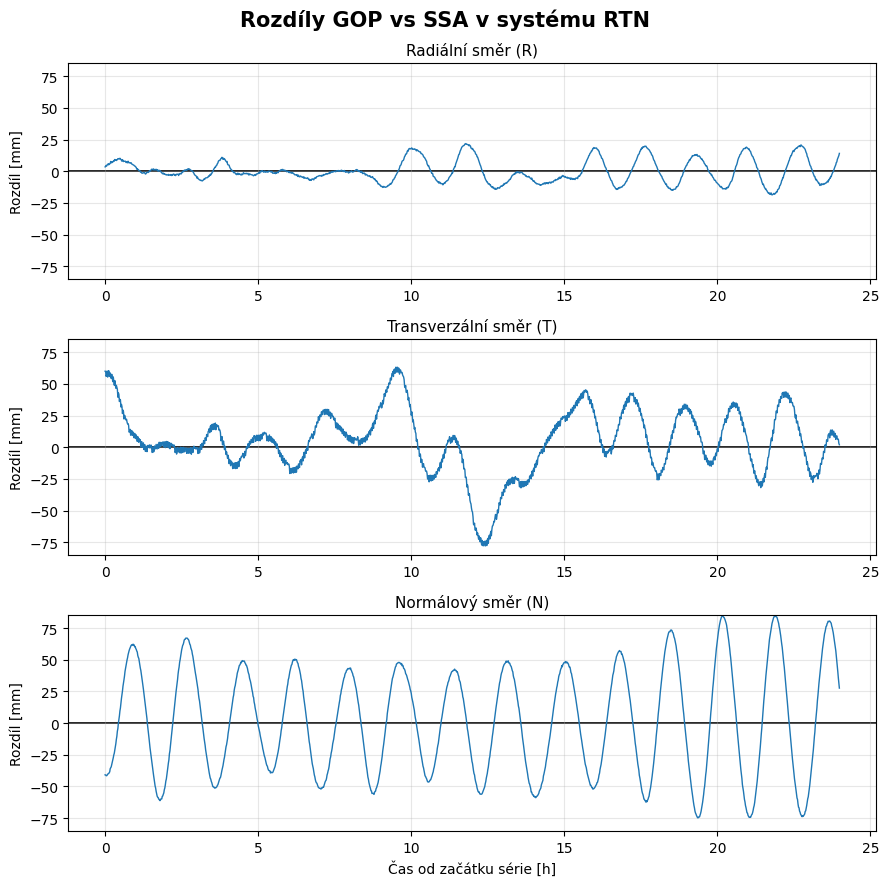

In [19]:
df = clean_df.copy()
t_hours = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds() / 3600.0

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["dR", "dT", "dN"]].values))
ylim = (-max_abs - 0.5, max_abs + 0.5)

for ax, (col, title) in zip(axes, components):
    ax.plot(t_hours, df[col].values, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=1.2, zorder=0)
    ax.set_ylabel("Rozdíl [mm]")
    ax.set_title(title, fontsize=11)
    ax.set_ylim(ylim)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Čas od začátku série [h]")
fig.suptitle("Rozdíly GOP vs SSA v systému RTN", fontsize=15, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_differences.pdf", bbox_inches="tight")
plt.show()


## RTN differences — histogram

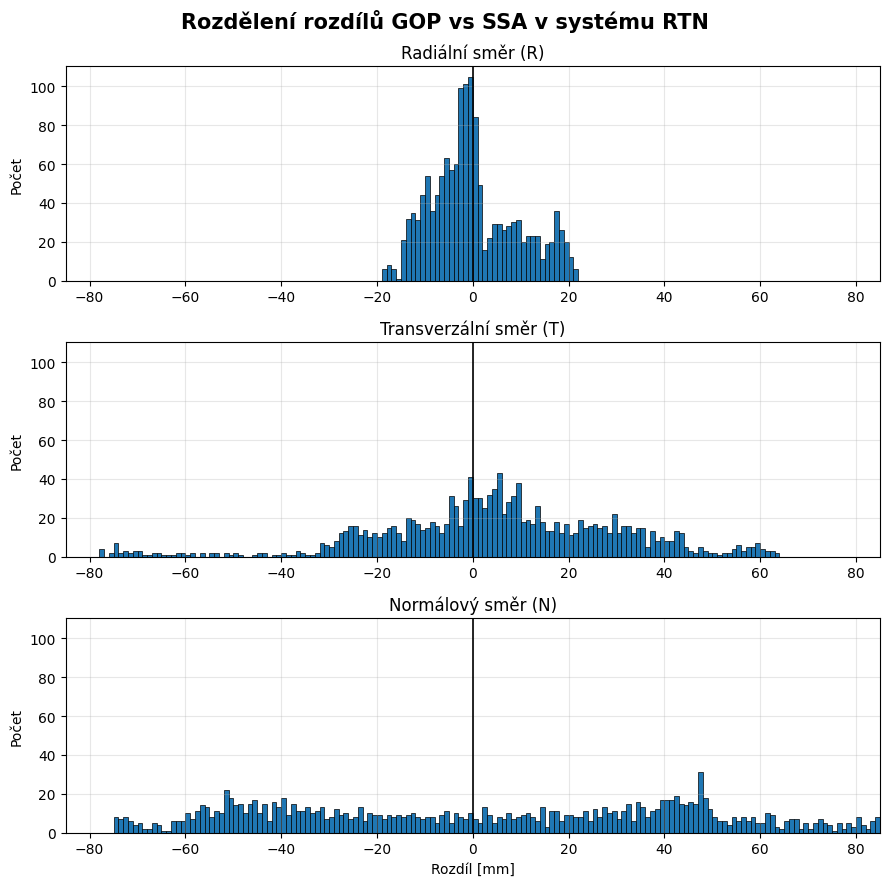

In [20]:
df = clean_df.copy()

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

max_abs = np.max(np.abs(df[["dR", "dT", "dN"]].values))
xmax = np.ceil(max_abs)
bins = np.arange(-xmax, xmax + 1, 1)

for ax, (col, title) in zip(axes, components):
    ax.hist(df[col].values, bins=bins, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=1.2)
    ax.set_ylabel("Počet")
    ax.set_title(title)
    ax.set_xlim(-xmax, xmax)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Rozdíl [mm]")
fig.suptitle("Rozdělení rozdílů GOP vs SSA v systému RTN", fontsize=15, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_histogram.pdf", bbox_inches="tight")
plt.show()


## RTN periodogram — Lomb-Scargle

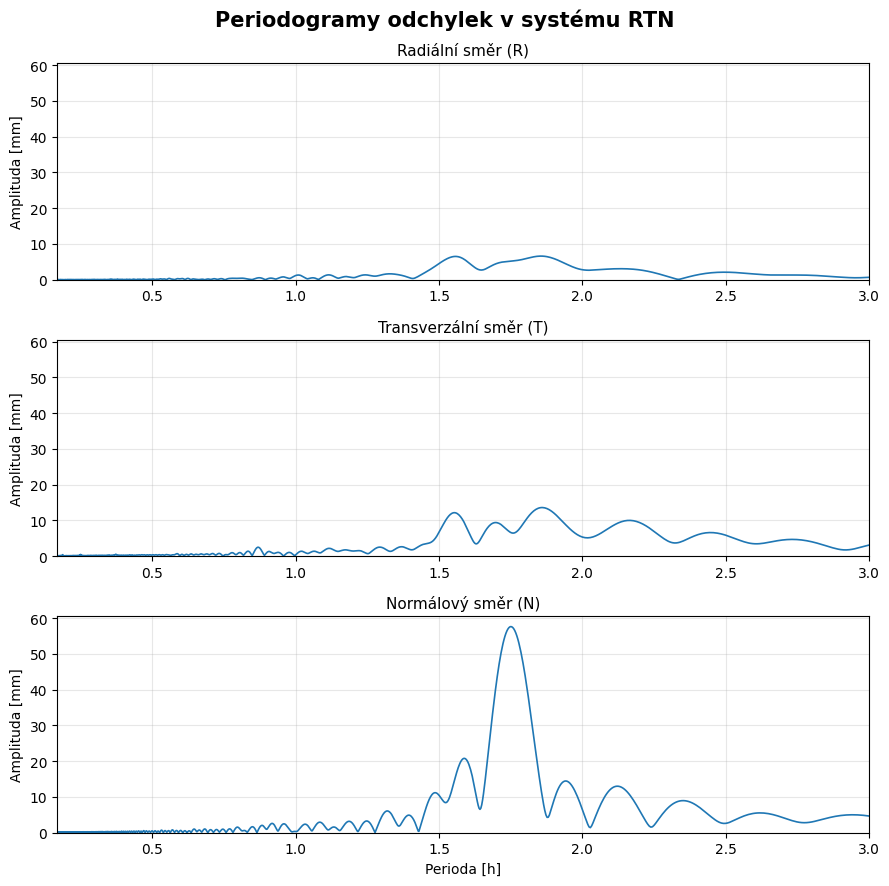

In [21]:
df = clean_df.copy()

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

t = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values
N = len(t)

f_min = 1 / (3 * 3600)
f_max = 1 / (10 * 60)
frequencies  = np.linspace(f_min, f_max, 5000)
angular_freq = 2 * np.pi * frequencies
periods      = 1 / frequencies / 3600  # hours
mask         = periods > 0.5

CHUNK_SIZE = 250
periodograms = {}
global_max = 0

for col, _ in components:
    y = df[col].values - df[col].mean()
    pgram_parts = [
        lombscargle(t, y, angular_freq[i:i + CHUNK_SIZE])
        for i in range(0, len(angular_freq), CHUNK_SIZE)
    ]
    pgram     = np.concatenate(pgram_parts)
    amplitude = 2 * np.sqrt(pgram / N)
    periodograms[col] = amplitude
    local_max = np.max(amplitude[mask])
    if local_max > global_max:
        global_max = local_max

for ax, (col, title) in zip(axes, components):
    ax.plot(periods, periodograms[col], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(periods.min(), periods.max())
fig.suptitle("Periodogramy odchylek v systému RTN", fontsize=15, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_periodograms_lomb_scargle.pdf", bbox_inches="tight")
plt.show()


## RTN periodogram — FFT

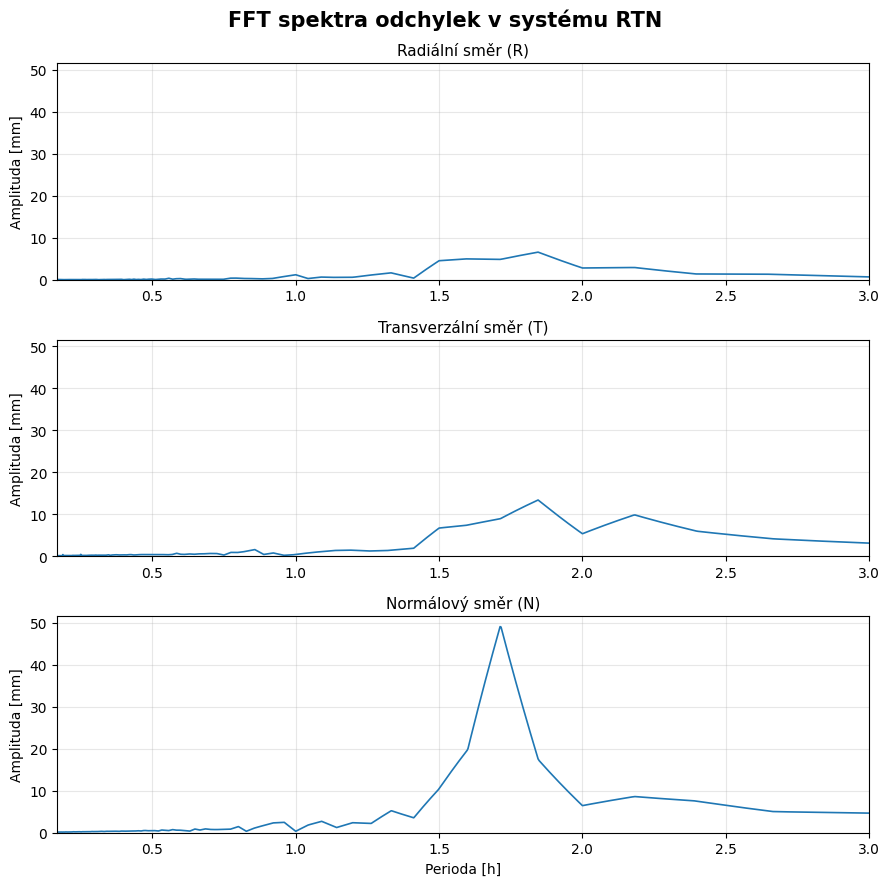

In [22]:
df = clean_df.copy()

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, sharey=True)

components = [
    ("dR", "Radiální směr (R)"),
    ("dT", "Transverzální směr (T)"),
    ("dN", "Normálový směr (N)"),
]

t  = (df["epoch_datetime"] - df["epoch_datetime"].iloc[0]).dt.total_seconds().values
N  = len(t)
dt = np.median(np.diff(t))

f_min = 1 / (3 * 3600)
f_max = 1 / (10 * 60)
frequencies = np.linspace(f_min, f_max, 5000)
periods     = 1 / frequencies / 3600  # hours
mask        = periods > 0.5

periodograms = {}
global_max = 0

for col, _ in components:
    y = df[col].values - df[col].mean()
    fft_vals  = np.fft.rfft(y)[1:]
    fft_freqs = np.fft.rfftfreq(N, d=dt)[1:]
    fft_amp   = 2 * np.abs(fft_vals) / N
    amplitude = np.interp(frequencies, fft_freqs, fft_amp, left=np.nan, right=np.nan)
    periodograms[col] = amplitude
    local_max = np.nanmax(amplitude[mask])
    if local_max > global_max:
        global_max = local_max

for ax, (col, title) in zip(axes, components):
    ax.plot(periods, periodograms[col], linewidth=1.2, zorder=2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Amplituda [mm]")
    ax.set_ylim(0, global_max * 1.05)
    ax.tick_params(axis="x", labelbottom=True)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Perioda [h]")
axes[-1].set_xlim(periods.min(), periods.max())
fig.suptitle("FFT spektra odchylek v systému RTN", fontsize=15, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_doy_str}_rtn_periodograms_fft.pdf", bbox_inches="tight")
plt.show()


## Daily RTN RMS over time

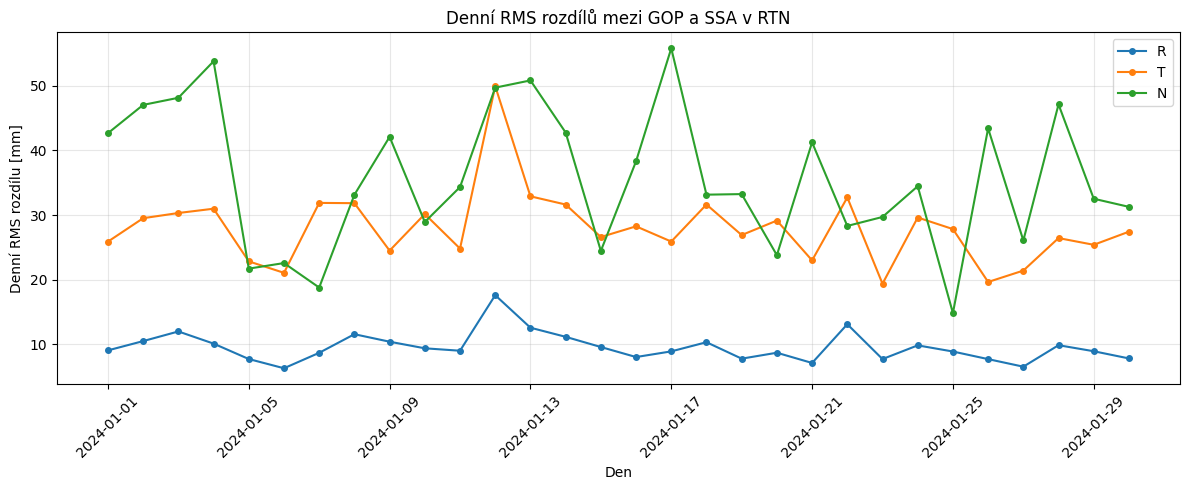

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plot_df["day"], plot_df["R_rms"] * 1000, "o-", linewidth=1.5, markersize=4, label="R")
ax.plot(plot_df["day"], plot_df["T_rms"] * 1000, "o-", linewidth=1.5, markersize=4, label="T")
ax.plot(plot_df["day"], plot_df["N_rms"] * 1000, "o-", linewidth=1.5, markersize=4, label="N")

ax.set_xlabel("Den")
ax.set_ylabel("Denní RMS rozdílu [mm]")
ax.set_title("Denní RMS rozdílů mezi GOP a SSA v RTN")
ax.grid(True, alpha=0.3)
ax.legend()

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_rtn_rms.pdf", bbox_inches="tight")
plt.show()


## Daily 3D RMS over time

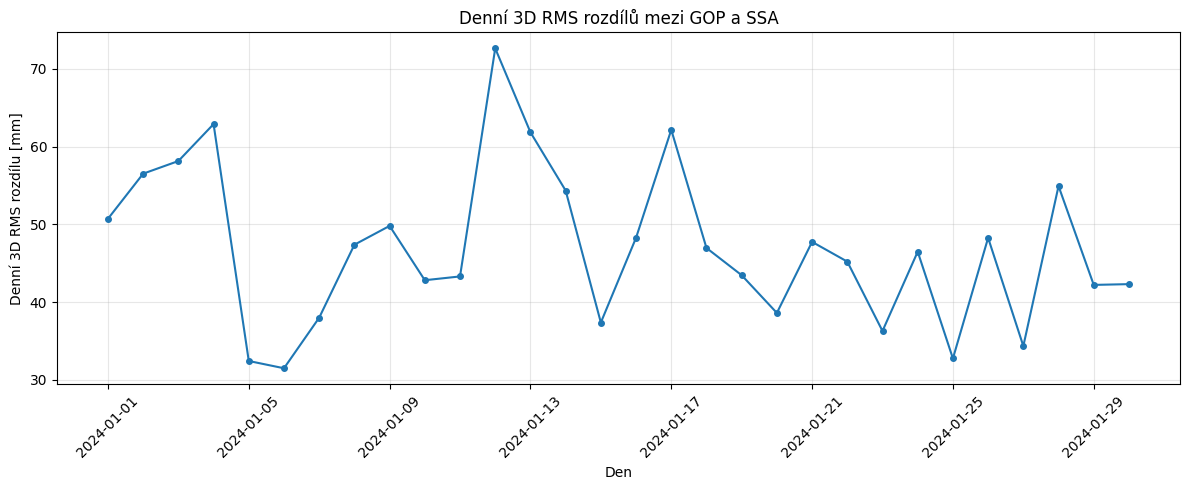

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plot_df["day"], plot_df["3D_rms"] * 1000, "o-", linewidth=1.5, markersize=4)

ax.set_xlabel("Den")
ax.set_ylabel("Denní 3D RMS rozdílu [mm]")
ax.set_title("Denní 3D RMS rozdílů mezi GOP a SSA")
ax.grid(True, alpha=0.3)

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_3d_rms.pdf", bbox_inches="tight")
plt.show()


## Daily RTN mean differences

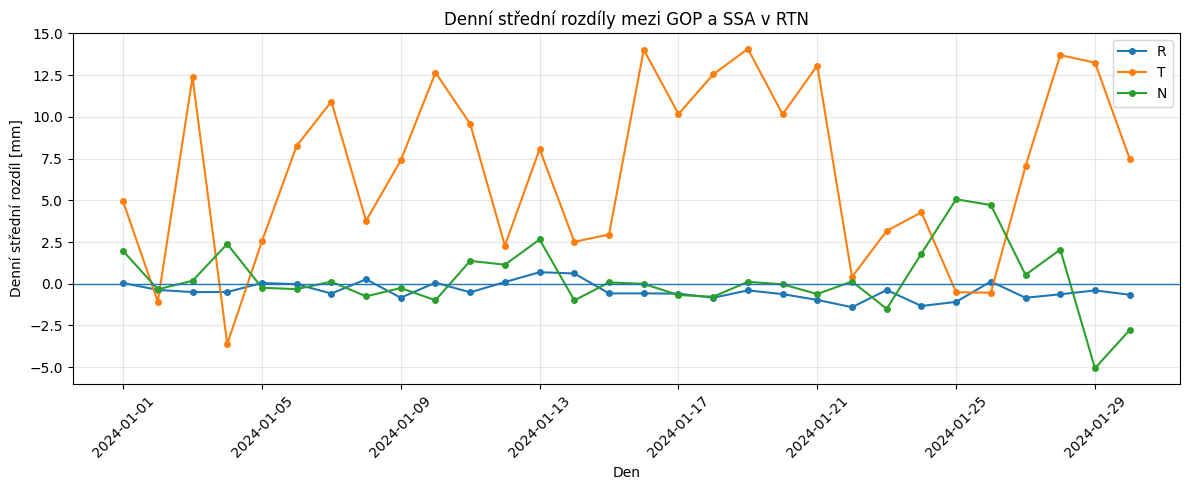

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plot_df["day"], plot_df["R_mean"] * 1000, "o-", linewidth=1.5, markersize=4, label="R")
ax.plot(plot_df["day"], plot_df["T_mean"] * 1000, "o-", linewidth=1.5, markersize=4, label="T")
ax.plot(plot_df["day"], plot_df["N_mean"] * 1000, "o-", linewidth=1.5, markersize=4, label="N")

ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel("Den")
ax.set_ylabel("Denní střední rozdíl [mm]")
ax.set_title("Denní střední rozdíly mezi GOP a SSA v RTN")
ax.grid(True, alpha=0.3)
ax.legend()

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_rtn_mean.pdf", bbox_inches="tight")
plt.show()


## Daily RMS vs RMS0

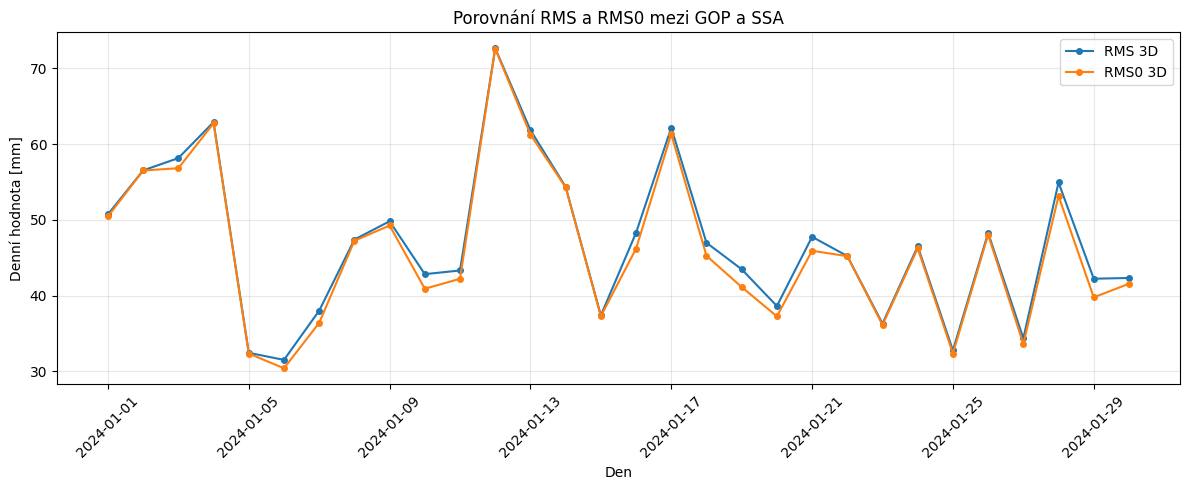

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(plot_df["day"], plot_df["3D_rms"]  * 1000, "o-", linewidth=1.5, markersize=4, label="RMS 3D")
ax.plot(plot_df["day"], plot_df["3D_rms0"] * 1000, "o-", linewidth=1.5, markersize=4, label="RMS0 3D")

ax.set_xlabel("Den")
ax.set_ylabel("Denní hodnota [mm]")
ax.set_title("Porovnání RMS a RMS0 mezi GOP a SSA")
ax.grid(True, alpha=0.3)
ax.legend()

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_3d_rms_vs_rms0.pdf", bbox_inches="tight")
plt.show()


## Daily RTN RMS — boxplot

C:\Users\michal\AppData\Local\Temp\ipykernel_24824\2560894477.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["R", "T", "N"])


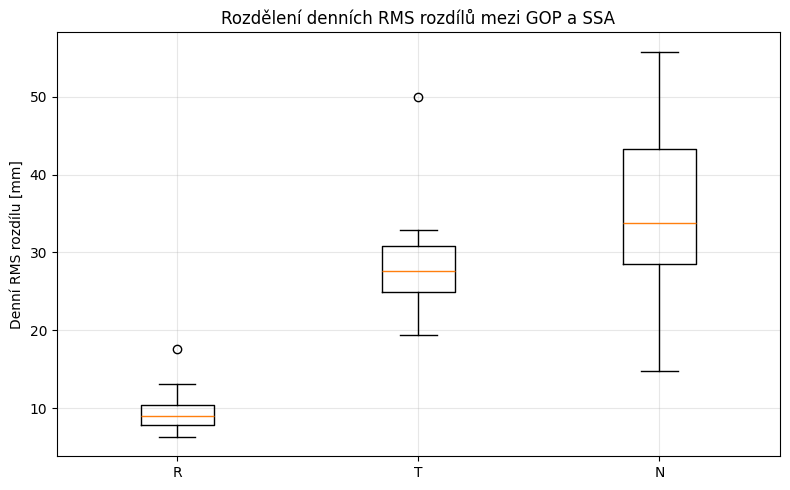

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [
    plot_df["R_rms"].dropna() * 1000,
    plot_df["T_rms"].dropna() * 1000,
    plot_df["N_rms"].dropna() * 1000,
]

ax.boxplot(data, labels=["R", "T", "N"])
ax.set_ylabel("Denní RMS rozdílu [mm]")
ax.set_title("Rozdělení denních RMS rozdílů mezi GOP a SSA")
ax.grid(True, alpha=0.3)

_plot_days = pd.to_datetime(plot_df["day"]).dt.date.tolist()
_pd_start  = min(_plot_days).timetuple().tm_yday
_pd_end    = max(_plot_days).timetuple().tm_yday
_pd_str    = f"doy{_pd_start:03d}" if _pd_start == _pd_end else f"doy{_pd_start:03d}-doy{_pd_end:03d}"

plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{SOLUTION_TAG}_{satellite}_{_pd_str}_daily_rtn_rms_boxplot.pdf", bbox_inches="tight")
plt.show()


## Summary table

In [28]:
summary_table = pd.DataFrame({
    "component": ["R", "T", "N", "3D"],
    "mean_of_mean_mm": [
        plot_df["R_mean"].mean()  * 1000,
        plot_df["T_mean"].mean()  * 1000,
        plot_df["N_mean"].mean()  * 1000,
        plot_df["3D_mean"].mean() * 1000,
    ],
    "mean_rms_mm": [
        plot_df["R_rms"].mean()  * 1000,
        plot_df["T_rms"].mean()  * 1000,
        plot_df["N_rms"].mean()  * 1000,
        plot_df["3D_rms"].mean() * 1000,
    ],
    "median_rms_mm": [
        plot_df["R_rms"].median()  * 1000,
        plot_df["T_rms"].median()  * 1000,
        plot_df["N_rms"].median()  * 1000,
        plot_df["3D_rms"].median() * 1000,
    ],
    "max_rms_mm": [
        plot_df["R_rms"].max()  * 1000,
        plot_df["T_rms"].max()  * 1000,
        plot_df["N_rms"].max()  * 1000,
        plot_df["3D_rms"].max() * 1000,
    ],
    "mean_rms0_mm": [
        plot_df["R_rms0"].mean()  * 1000,
        plot_df["T_rms0"].mean()  * 1000,
        plot_df["N_rms0"].mean()  * 1000,
        plot_df["3D_rms0"].mean() * 1000,
    ],
})

summary_table


,component,mean_of_mean_mm,mean_rms_mm,median_rms_mm,max_rms_mm,mean_rms0_mm
0,R,-0.42445,9.55571,9.02697,17.60036,9.53283
1,T,6.86439,27.98699,27.63118,49.95757,26.54756
2,N,0.29703,35.81433,33.79426,55.81422,35.74522
3,3D,7.75943,47.00138,46.73601,72.65242,46.12777
